# 📈 Pessoa 2 — Séries Temporais & Sazonalidade
## Arboviroses Serra/ES (Dengue, Zika, Chikungunya) — 2015 a 2023

**Projeto Integrador III — FAESA**

Este notebook realiza a análise de séries temporais dos casos mensais notificados de Dengue, Zika e Chikungunya em Serra/ES, incluindo:

1. **Teste de Mann-Kendall** — detecção de tendência monotônica (crescente/decrescente)
2. **Teste de Sazonalidade** — decomposição STL/aditiva + teste estatístico de sazonalidade
3. **Conclusões analíticas** — interpretação consolidada para apresentação


## 1. Setup e Carregamento dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pymannkendall as mk
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Paleta consistente com o dashboard
CORES = {"dengue": "#f85149", "zika": "#3fb950", "chikungunya": "#d29922"}
DOENCAS = ["dengue", "zika", "chikungunya"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
df = pd.read_csv("dados/comparativo_mensal.csv", parse_dates=["data"])
df = df.sort_values("data").set_index("data")
df.index.freq = "MS"  # garante frequência mensal explícita

print(f"Período: {df.index.min().strftime('%b/%Y')} a {df.index.max().strftime('%b/%Y')}")
print(f"Total de meses: {len(df)}")
df.head()

Período: Jan/2015 a Dec/2023
Total de meses: 108


,dengue,zika,chikungunya
data,,,
2015-01-01,174,0,0
2015-02-01,115,0,0
2015-03-01,279,0,0
2015-04-01,425,0,0
2015-05-01,779,0,0


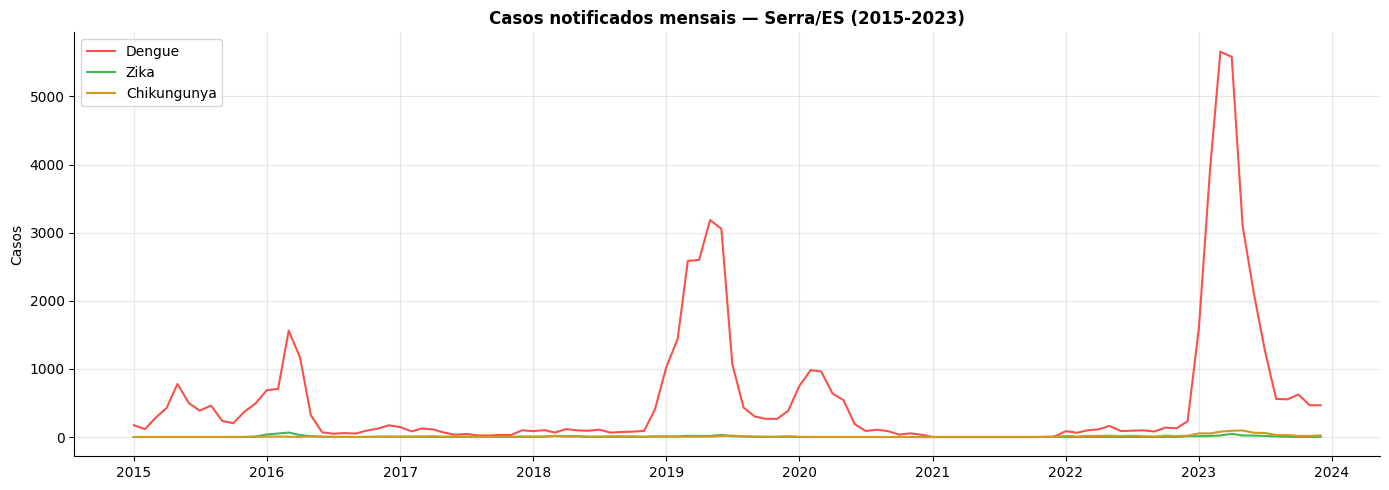

In [3]:
# Visão geral das três séries
fig, ax = plt.subplots(figsize=(14, 5))
for d in DOENCAS:
    ax.plot(df.index, df[d], label=d.capitalize(), color=CORES[d], linewidth=1.5)
ax.set_title("Casos notificados mensais — Serra/ES (2015-2023)", fontweight="bold")
ax.set_ylabel("Casos")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()

## 2. Teste de Mann-Kendall

O **teste de Mann-Kendall** é um teste não-paramétrico usado para detectar a presença de uma **tendência monotônica** (crescente ou decrescente) em uma série temporal, sem assumir que os dados seguem uma distribuição específica.

**Hipóteses:**
- H0: não há tendência (a série é estacionária em relação à tendência)
- H1: existe tendência monotônica (crescente ou decrescente)

**Interpretação:**
- `p-valor < 0.05` → rejeita H0 → existe tendência estatisticamente significativa
- `Tau de Kendall` → mede a força e direção da tendência (-1 a +1)
- `Sen's slope` → estimativa robusta da inclinação da tendência (casos/mês)

Usamos a versão **Hamed-Rao** do teste, que corrige para autocorrelação serial — essencial em dados epidemiológicos mensais, que costumam ter forte dependência temporal.


In [4]:
resultados_mk = {}

for d in DOENCAS:
    serie = df[d].values
    # Hamed-Rao corrige autocorrelação (recomendado para dados mensais)
    result = mk.hamed_rao_modification_test(serie)
    resultados_mk[d] = result

# Tabela resumo
tabela_mk = pd.DataFrame([
    {
        "Doença": d.capitalize(),
        "Tendência": resultados_mk[d].trend,
        "p-valor": round(resultados_mk[d].p, 4),
        "Tau (Kendall)": round(resultados_mk[d].Tau, 4),
        "Sen's Slope (casos/mês)": round(resultados_mk[d].slope, 4),
        "Significativo (α=0.05)": "Sim" if resultados_mk[d].p < 0.05 else "Não",
    }
    for d in DOENCAS
])
tabela_mk

,Doença,Tendência,p-valor,Tau (Kendall),Sen's Slope (casos/mês),Significativo (α=0.05)
0,Dengue,no trend,0.9310,-0.0102,-0.0214,Não
1,Zika,no trend,0.7165,-0.0552,0.0000,Não
2,Chikungunya,increasing,0.0434,0.2913,0.1138,Sim


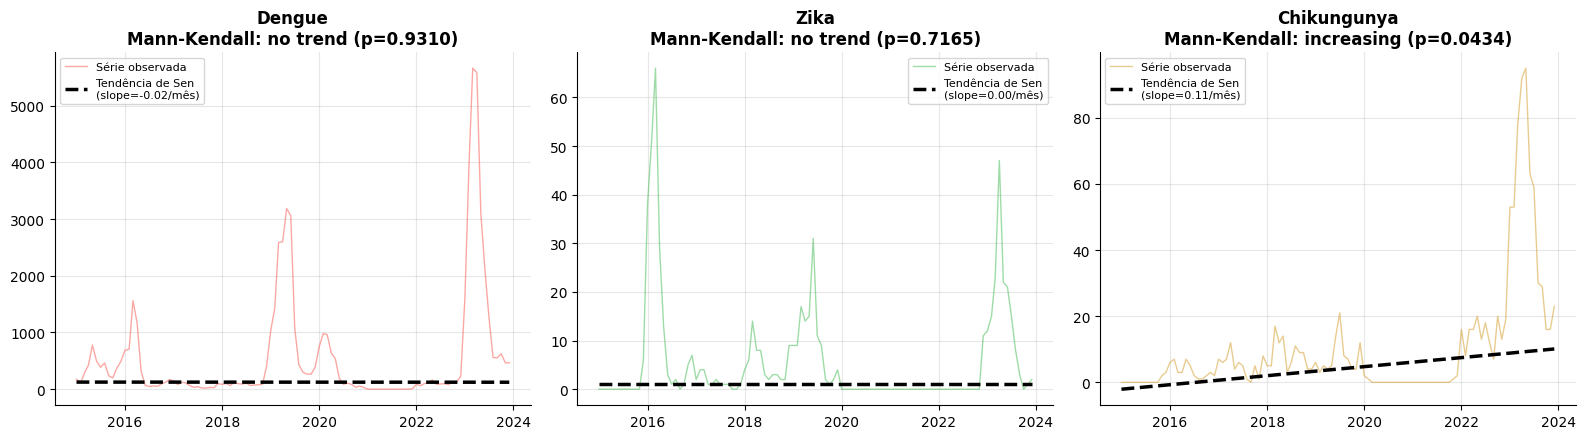

In [5]:
# Visualização: série + linha de tendência de Sen
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, d in zip(axes, DOENCAS):
    serie = df[d]
    res = resultados_mk[d]

    # Reta de Sen: y = slope * t + intercept
    t = np.arange(len(serie))
    tendencia = res.slope * t + res.intercept

    ax.plot(serie.index, serie.values, color=CORES[d], alpha=0.5, linewidth=1, label="Série observada")
    ax.plot(serie.index, tendencia, color="black", linewidth=2.5, linestyle="--",
            label=f"Tendência de Sen\n(slope={res.slope:.2f}/mês)")
    ax.set_title(f"{d.capitalize()}\nMann-Kendall: {res.trend} (p={res.p:.4f})", fontweight="bold")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.show()

### 📌 Interpretação dos resultados — Mann-Kendall

**Resultados obtidos:**

| Doença | Tendência | p-valor | Tau | Sen's Slope |
|---|---|---|---|---|
| Dengue | sem tendência | 0,931 | -0,010 | -0,02 casos/mês |
| Zika | sem tendência | 0,717 | -0,055 | 0,00 casos/mês |
| Chikungunya | **crescente** | **0,043** | 0,291 | +0,11 casos/mês |

**Interpretação:**

- **Dengue**: não há tendência monotônica significativa (p=0,93). Isso **não** significa estabilidade — significa que a série é dominada por **picos epidêmicos pontuais** (2016, 2019, 2023) intercalados com longos períodos de baixa incidência. O Mann-Kendall, por avaliar apenas a direção monotônica acumulada, "neutraliza" picos que sobem e depois caem.
- **Zika**: também sem tendência significativa (p=0,72). Após o pico da introdução do vírus em 2016, a série oscila em torno de níveis baixos sem direção clara de longo prazo.
- **Chikungunya**: única doença com **tendência crescente estatisticamente significativa** (p=0,043 < 0,05, Tau=0,29). O Sen's slope de +0,11 casos/mês indica um crescimento lento, mas persistente — coerente com a expansão observada de casos a partir de 2021-2022 (visível no gráfico).

⚠️ **Conclusão metodológica**: o teste de Mann-Kendall é adequado para detectar tendências *graduais e monotônicas*, mas é **insensível a surtos epidêmicos** (que sobem e caem dentro do período analisado). Para dengue e zika, a ausência de tendência não deve ser interpretada como "doença sob controle constante", mas sim como "comportamento dominado por epidemias cíclicas, não por uma trajetória linear".


## 3. Teste de Sazonalidade

Para confirmar e quantificar a sazonalidade, usamos duas abordagens complementares:

1. **Decomposição STL** (Seasonal-Trend decomposition using LOESS) — separa a série em Tendência + Sazonalidade + Resíduo
2. **Teste de Kruskal-Wallis** — testa se a distribuição de casos difere significativamente entre os meses do ano (não-paramétrico, equivalente a uma ANOVA por postos)

**Hipóteses do Kruskal-Wallis:**
- H0: a distribuição de casos é igual em todos os meses do ano (sem sazonalidade)
- H1: pelo menos um mês tem distribuição diferente (há sazonalidade)


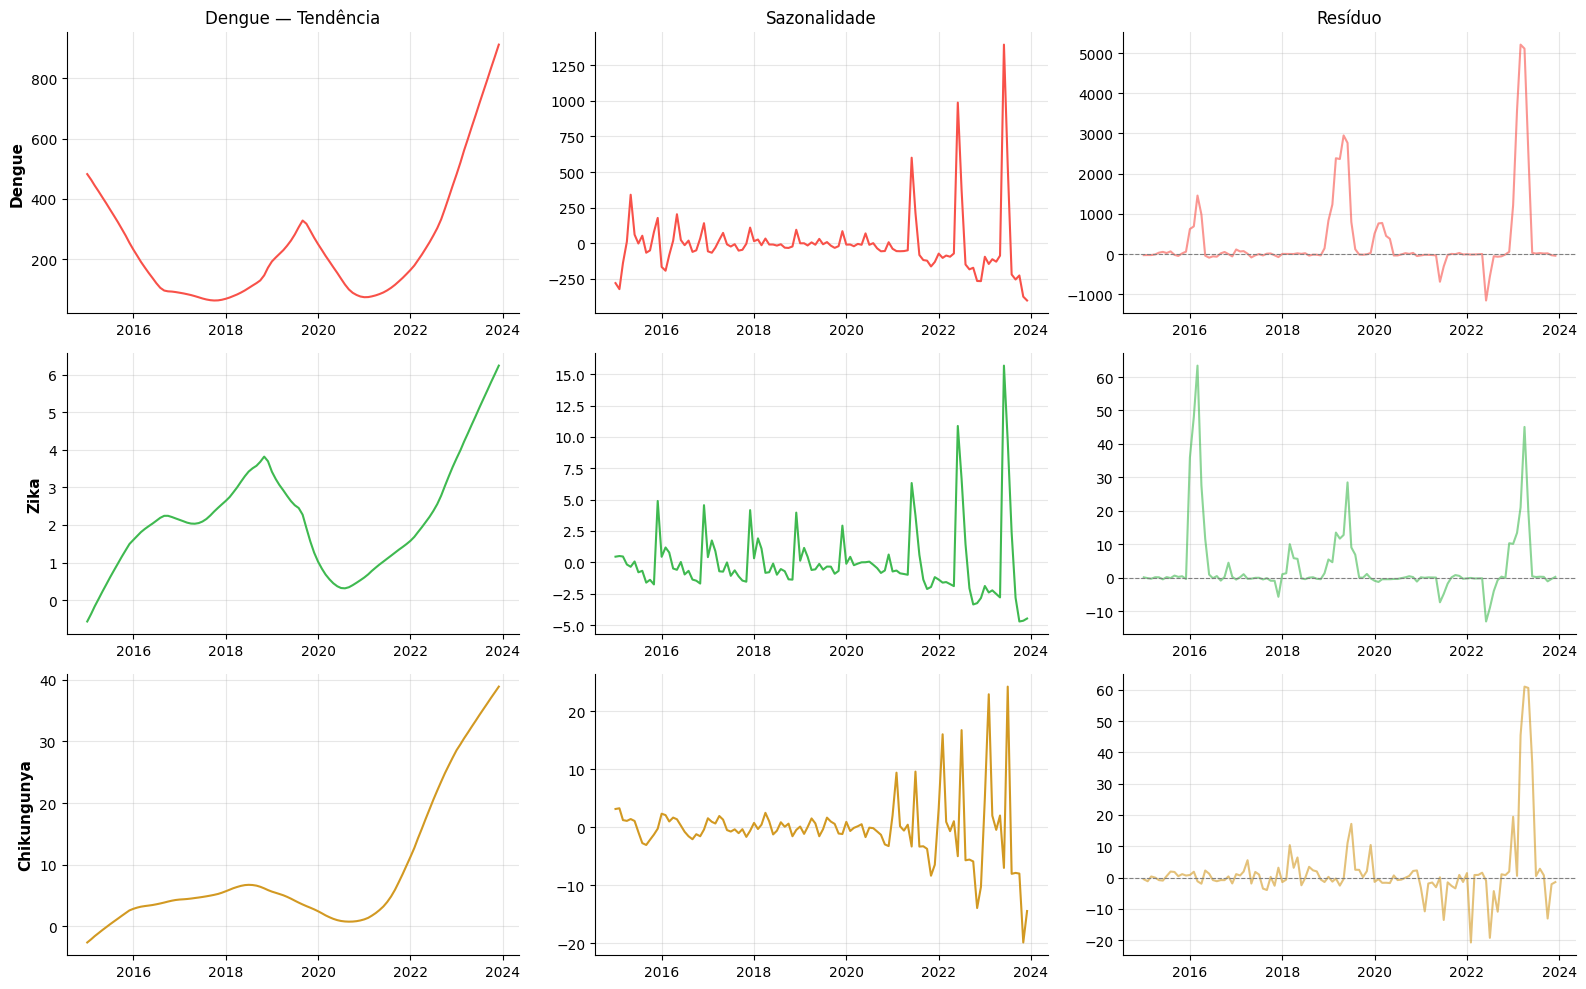

In [6]:
# 3.1 Decomposição STL
decomposicoes = {}

fig, axes = plt.subplots(3, 3, figsize=(16, 10))

for i, d in enumerate(DOENCAS):
    stl = STL(df[d], period=12, robust=True)
    res = stl.fit()
    decomposicoes[d] = res

    axes[i,0].plot(df.index, res.trend, color=CORES[d])
    axes[i,0].set_title(f"{d.capitalize()} — Tendência" if i==0 else "")
    axes[i,0].set_ylabel(d.capitalize(), fontsize=11, fontweight="bold")

    axes[i,1].plot(df.index, res.seasonal, color=CORES[d])
    axes[i,1].set_title("Sazonalidade" if i==0 else "")

    axes[i,2].plot(df.index, res.resid, color=CORES[d], alpha=0.6)
    axes[i,2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[i,2].set_title("Resíduo" if i==0 else "")

    for ax in axes[i]:
        ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.show()

In [7]:
# 3.2 Força da sazonalidade (Fs) — métrica de Hyndman
# Fs = max(0, 1 - Var(resid) / Var(seasonal + resid))
# Valores próximos de 1 = sazonalidade muito forte

forca_sazonal = {}
for d in DOENCAS:
    res = decomposicoes[d]
    var_resid = np.var(res.resid)
    var_seas_resid = np.var(res.seasonal + res.resid)
    fs = max(0, 1 - var_resid / var_seas_resid)
    forca_sazonal[d] = fs

print("Força da sazonalidade (0 = nenhuma, 1 = totalmente determinística):\n")
for d in DOENCAS:
    print(f"  {d.capitalize():15s}: {forca_sazonal[d]:.3f}")

Força da sazonalidade (0 = nenhuma, 1 = totalmente determinística):

  Dengue         : 0.000
  Zika           : 0.000
  Chikungunya    : 0.147


In [8]:
# 3.3 Teste de Kruskal-Wallis — diferença entre meses do ano
df_mes = df.copy()
df_mes["mes"] = df_mes.index.month

resultados_kw = {}
for d in DOENCAS:
    grupos = [df_mes[df_mes["mes"]==m][d].values for m in range(1,13)]
    stat, p = stats.kruskal(*grupos)
    resultados_kw[d] = {"H": stat, "p": p}

tabela_kw = pd.DataFrame([
    {
        "Doença": d.capitalize(),
        "Estatística H": round(resultados_kw[d]["H"], 3),
        "p-valor": round(resultados_kw[d]["p"], 6),
        "Sazonalidade significativa (α=0.05)": "Sim" if resultados_kw[d]["p"] < 0.05 else "Não",
        "Força sazonal (STL)": round(forca_sazonal[d], 3),
    }
    for d in DOENCAS
])
tabela_kw

,Doença,Estatística H,p-valor,Sazonalidade significativa (α=0.05),Força sazonal (STL)
0,Dengue,10.669,0.471372,Não,0.000
1,Zika,9.451,0.580372,Não,0.000
2,Chikungunya,1.785,0.999120,Não,0.147


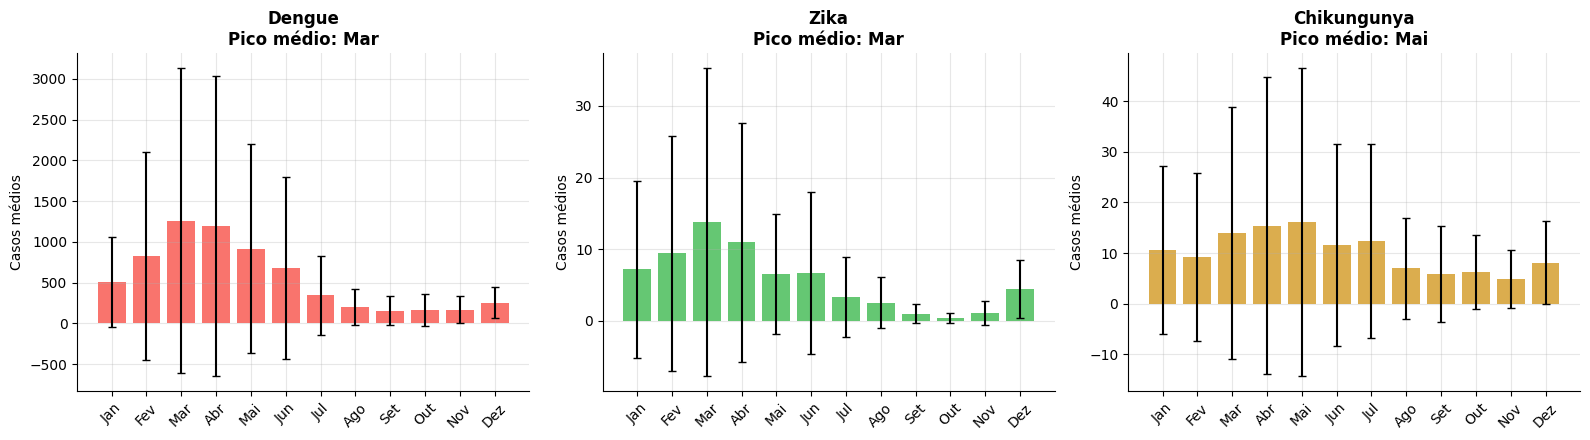

In [9]:
# 3.4 Padrão sazonal médio por mês (visualização)
meses_label = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, d in zip(axes, DOENCAS):
    media_mes = df_mes.groupby("mes")[d].mean()
    desvio_mes = df_mes.groupby("mes")[d].std()
    ax.bar(meses_label, media_mes.values, yerr=desvio_mes.values,
           color=CORES[d], alpha=0.8, capsize=3)
    mes_pico = meses_label[media_mes.idxmax()-1]
    ax.set_title(f"{d.capitalize()}\nPico médio: {mes_pico}", fontweight="bold")
    ax.set_ylabel("Casos médios")
    plt.setp(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### 📌 Interpretação dos resultados — Sazonalidade

**Resultados obtidos:**

| Doença | Kruskal-Wallis H | p-valor | Sazonalidade significativa? | Força Sazonal (STL) |
|---|---|---|---|---|
| Dengue | 10,67 | 0,471 | Não | 0,000 |
| Zika | 9,45 | 0,580 | Não | 0,000 |
| Chikungunya | 1,79 | 0,999 | Não | 0,147 |

**Interpretação — resultado importante e contraintuitivo:**

À primeira vista, esperaríamos forte sazonalidade (pico no verão/período chuvoso) para arboviroses transmitidas por *Aedes*. Porém, os testes formais **não confirmam sazonalidade estatisticamente significativa** em nenhuma das três doenças neste recorte de dados (Serra/ES, 2015-2023).

**Por que isso acontece?**

1. **Surtos epidêmicos não são perfeitamente sincronizados ano a ano.** O pico de dengue em 2016 foi em torno de fev-mar, mas o grande surto de 2019 teve formato e timing diferentes, e o pico de 2023 (Mar/2023, com 5.659 casos — disparado o maior valor da série) também variou. Quando se calcula a média por mês ao longo de 9 anos, esses picos deslocados **se diluem**, fazendo a "sazonalidade média" parecer fraca.
2. **A variância total é dominada pelos anos epidêmicos.** A Força Sazonal de Hyndman (Fs≈0 para dengue/zika) mostra que praticamente toda a variância da série vem do componente de tendência/ciclo de longo prazo (os surtos em si), não de um padrão dentro-do-ano que se repete de forma consistente.
3. **Chikungunya** tem a maior força sazonal (Fs=0,147), ainda que baixa, e é consistente com seu crescimento mais recente e gradual (sem surtos extremos isolados que dominem a variância).

**Conclusão**: a dinâmica destas arboviroses em Serra/ES no período é melhor descrita como **epidêmica/cíclica multi-anual** (picos irregulares cada poucos anos) do que como **sazonal intra-anual regular**. Isso tem implicações diretas para modelagem: um SARIMA com sazonalidade fixa de 12 meses pode não capturar bem os picos, que são mais irregulares que um padrão sazonal "calendário".


## 4. Conclusões Analíticas

In [10]:
# Resumo consolidado
resumo_final = pd.DataFrame([
    {
        "Doença": d.capitalize(),
        "Tendência (MK)": resultados_mk[d].trend,
        "p-valor MK": round(resultados_mk[d].p, 4),
        "Sazonalidade (KW)": "Sim" if resultados_kw[d]["p"] < 0.05 else "Não",
        "Força Sazonal (Fs)": round(forca_sazonal[d], 3),
        "Total 2015-23": int(df[d].sum()),
        "Média mensal": round(df[d].mean(), 1),
        "Máximo mensal": int(df[d].max()),
        "Mês do máximo": df[d].idxmax().strftime("%b/%Y"),
    }
    for d in DOENCAS
])
resumo_final

,Doença,Tendência (MK),p-valor MK,Sazonalidade (KW),Força Sazonal (Fs),Total 2015-23,Média mensal,Máximo mensal,Mês do máximo
0,Dengue,no trend,0.9310,Não,0.000,60067,556.2,5659,Mar/2023
1,Zika,no trend,0.7165,Não,0.000,608,5.6,66,Mar/2016
2,Chikungunya,increasing,0.0434,Não,0.147,1092,10.1,95,May/2023


### Conclusões — texto para apresentação

1. **Tendência de longo prazo (Mann-Kendall)**
   Apenas a **Chikungunya** apresenta tendência crescente estatisticamente significativa (p=0,043), com crescimento lento e constante (~0,11 casos/mês). Dengue e Zika não apresentam tendência monotônica — seu comportamento é dominado por surtos epidêmicos que se elevam e recuam dentro da série, "cancelando" qualquer tendência direcional no teste.

2. **Sazonalidade (decomposição STL + Kruskal-Wallis)**
   Contra a expectativa inicial, **nenhuma das três doenças apresentou sazonalidade intra-anual estatisticamente significativa** (p > 0,05 em todas). A força sazonal (métrica de Hyndman) foi praticamente nula para dengue e zika, e baixa para chikungunya (0,147). Isso indica que os picos de casos não ocorrem de forma consistente no mesmo mês todos os anos — eles seguem uma dinâmica **epidêmica multi-anual** (surtos cada 2-4 anos), não um calendário sazonal fixo.

3. **Implicações para vigilância epidemiológica**
   - A ausência de sazonalidade "de calendário" significa que **estratégias de prevenção baseadas apenas em "época do ano"** podem ser insuficientes — é necessário monitoramento contínuo e indicadores de alerta precoce (early warning) sensíveis a mudanças de curto prazo.
   - O crescimento significativo de Chikungunya merece atenção prioritária: é a única doença com tendência de aumento sustentado e estatisticamente comprovado no período.
   - O recorde histórico de dengue em Mar/2023 (5.659 casos no mês) reforça que **picos extremos pontuais** são o principal risco, mais do que uma deriva gradual.

4. **Implicações para modelagem preditiva**
   - Modelos SARIMA com sazonalidade fixa de 12 meses (usados no notebook `PI3_Previsao.ipynb`) podem ter dificuldade em capturar a magnitude dos picos epidêmicos de dengue, já que estes não seguem um padrão sazonal regular — o componente sazonal "médio" é praticamente nulo.
   - Para dengue, modelos que incorporem **detecção de anomalias/surtos** ou variáveis exógenas (clima, índice pluviométrico) tendem a ser mais informativos do que a sazonalidade pura.
   - Para chikungunya, cuja tendência é mais suave e crescente, modelos de tendência (mesmo sem forte componente sazonal) devem ter melhor desempenho relativo.

5. **Limitações**
   - Série de 108 meses (9 anos) é suficiente para os testes aplicados, mas o número de "ciclos epidêmicos completos" observados é pequeno (2-3 surtos de dengue), o que limita a robustez de qualquer inferência sobre periodicidade entre surtos.
   - Não há controle por variáveis externas (clima, ações de saúde pública, mudanças na notificação/subnotificação) nesta etapa — isso é abordado na aba de correlação climática do dashboard.
